# Student Performance — Preprocessing & Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv('data_for_ml.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (57, 7)


,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score
0,2.0,6.0,3.0,Male,Self Study,75.0,55.0
1,3.0,7.0,2.0,Female,Coaching,80.0,60.0
2,4.0,6.0,4.0,male,Self study,78.0,62.0
3,5.0,8.0,3.0,Femle,Group Study,85.0,70.0
4,6.0,7.0,5.0,Male,Self Study,88.0,72.0
5,7.0,6.0,6.0,Female,coaching,90.0,75.0
6,8.0,7.0,4.0,Male,Group study,92.0,80.0
7,2.0,5.0,7.0,Female,Self Study,70.0,50.0
8,3.0,6.0,6.0,Male,Self Study,75.0,55.0
9,4.0,7.0,5.0,Female,Group Study,82.0,65.0


In [3]:
df.info()
print()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours_Studied   56 non-null     float64
 1   Sleep_Hours     56 non-null     float64
 2   Internet_Usage  56 non-null     float64
 3   Gender          56 non-null     object 
 4   Study_Method    56 non-null     object 
 5   Attendance      56 non-null     float64
 6   Final_Score     56 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.2+ KB



,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score
count,56.000000,56.000000,56.000000,56,56,56.000000,56.000000
unique,NaN,NaN,NaN,4,6,NaN,NaN
top,NaN,NaN,NaN,Male,Self Study,NaN,NaN
freq,NaN,NaN,NaN,26,24,NaN,NaN
mean,5.178571,6.696429,4.678571,NaN,NaN,83.892857,68.196429
std,2.351844,1.025487,1.696061,NaN,NaN,8.725467,12.158678
min,1.000000,4.000000,1.000000,NaN,NaN,60.000000,40.000000
25%,3.000000,6.000000,3.750000,NaN,NaN,78.000000,60.000000
50%,5.000000,7.000000,5.000000,NaN,NaN,85.000000,69.000000
75%,7.000000,7.000000,6.000000,NaN,NaN,90.000000,75.250000


## Step 1: Handle Missing Values

In [4]:
print(df.isnull().sum())

for col in ['Gender', 'Study_Method']:
    df[col] = df[col].astype(object)

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter filling:")
print(df.isnull().sum())

Hours_Studied     1
Sleep_Hours       1
Internet_Usage    1
Gender            1
Study_Method      1
Attendance        1
Final_Score       1
dtype: int64

After filling:
Hours_Studied     0
Sleep_Hours       0
Internet_Usage    0
Gender            0
Study_Method      0
Attendance        0
Final_Score       0
dtype: int64


## Step 2: Remove Duplicates

In [5]:
print(f"Before: {len(df)} rows  |  Duplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After : {len(df)} rows")

Before: 57 rows  |  Duplicates: 25
After : 32 rows


## Step 3: Encode Categorical Features

In [6]:
df['Gender'] = df['Gender'].str.strip().str.lower().str.capitalize().replace({'Femle': 'Female'})
df['Study_Method'] = df['Study_Method'].str.strip().str.lower().str.title()

le_gender = LabelEncoder()
le_study  = LabelEncoder()
df['Gender_Encoded']       = le_gender.fit_transform(df['Gender'].astype(str))
df['Study_Method_Encoded'] = le_study.fit_transform(df['Study_Method'].astype(str))

print("Gender map      :", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print("Study_Method map:", dict(zip(le_study.classes_, le_study.transform(le_study.classes_))))

Gender map      : {'Female': np.int64(0), 'Male': np.int64(1)}
Study_Method map: {'Coaching': np.int64(0), 'Group Study': np.int64(1), 'Self Study': np.int64(2)}


## Step 4: Feature Scaling

In [7]:
features_to_scale = ['Hours_Studied', 'Sleep_Hours', 'Internet_Usage', 'Attendance']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df_scaled.head()

,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score,Gender_Encoded,Study_Method_Encoded
0,-1.391883,-0.655539,-0.838095,Male,Self Study,-1.034729,55.0,1,2
1,-0.997722,0.256515,-1.363959,Female,Coaching,-0.505794,60.0,0,0
2,-0.603560,-0.655539,-0.312232,Male,Self Study,-0.717368,62.0,1,2
3,-0.209398,1.168570,-0.838095,Female,Group Study,0.023141,70.0,0,1
4,0.184763,0.256515,0.213632,Male,Self Study,0.340502,72.0,1,2


## Train 5 Simple Linear Regression Models

In [8]:
y = df_scaled['Final_Score']

models_config = {
    "Model 1: Hours Studied" : ['Hours_Studied'],
    "Model 2: Attendance"    : ['Attendance'],
    "Model 3: Sleep Hours"   : ['Sleep_Hours'],
    "Model 4: Internet Usage": ['Internet_Usage'],
    "Model 5: Study Method"  : ['Study_Method_Encoded'],
}

results     = []
predictions = {}

for name, features in models_config.items():
    X = df_scaled[features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model'    : name,
        'Feature'  : features[0],
        'MAE'      : round(mean_absolute_error(y_test, y_pred), 4),
        'MSE'      : round(mean_squared_error(y_test, y_pred), 4),
        'R² Score' : round(r2_score(y_test, y_pred), 4),
    })
    predictions[name] = (y_test, y_pred)

    print(f"{name}  |  MAE: {results[-1]['MAE']}  MSE: {results[-1]['MSE']}  R²: {results[-1]['R² Score']}")

Model 1: Hours Studied  |  MAE: 3.3346  MSE: 15.4695  R²: 0.9341
Model 2: Attendance  |  MAE: 1.7629  MSE: 5.0478  R²: 0.9785
Model 3: Sleep Hours  |  MAE: 5.8396  MSE: 44.3541  R²: 0.811
Model 4: Internet Usage  |  MAE: 7.7457  MSE: 72.3958  R²: 0.6915
Model 5: Study Method  |  MAE: 13.9754  MSE: 277.6745  R²: -0.1831


## Model Comparison

In [9]:
results_df = pd.DataFrame(results)

def highlight_best(s):
    if s.name == 'R² Score':
        return ['background-color: #d4edda; font-weight:bold' if v == s.max() else '' for v in s]
    if s.name in ['MAE', 'MSE']:
        return ['background-color: #d4edda; font-weight:bold' if v == s.min() else '' for v in s]
    return ['' for _ in s]

results_df.style.apply(highlight_best, subset=['MAE', 'MSE', 'R² Score'])

,Model,Feature,MAE,MSE,R² Score
0,Model 1: Hours Studied,Hours_Studied,3.334600,15.469500,0.934100
1,Model 2: Attendance,Attendance,1.762900,5.047800,0.978500
2,Model 3: Sleep Hours,Sleep_Hours,5.839600,44.354100,0.811000
3,Model 4: Internet Usage,Internet_Usage,7.745700,72.395800,0.691500
4,Model 5: Study Method,Study_Method_Encoded,13.975400,277.674500,-0.183100


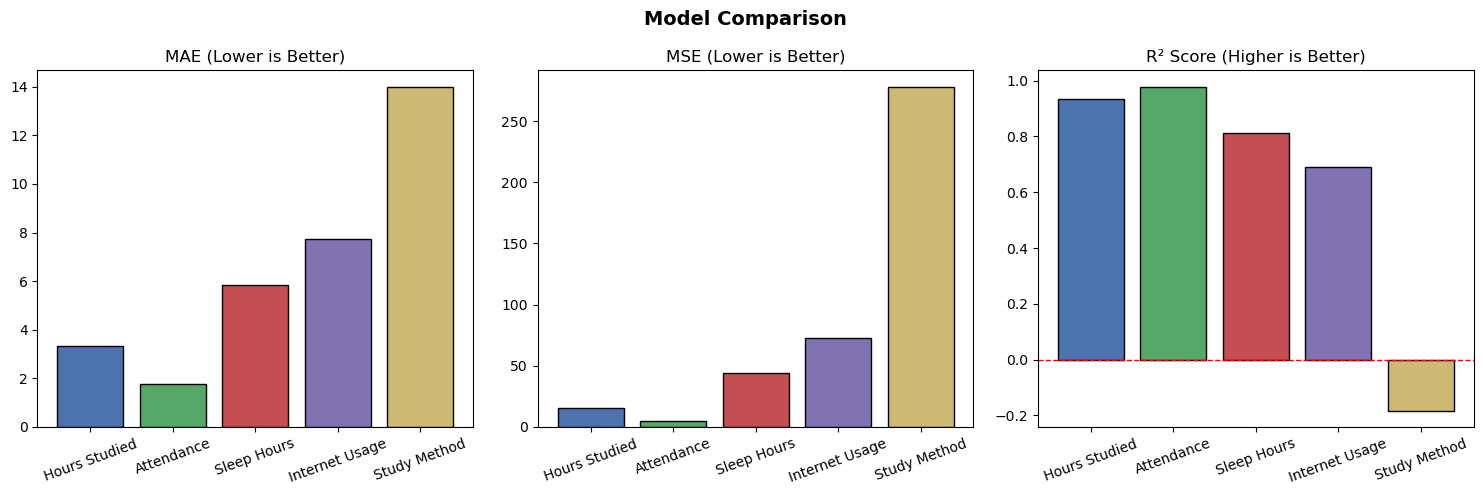

In [10]:
labels = [r['Model'].split(': ')[1] for r in results]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, title in zip(axes, ['MAE', 'MSE', 'R² Score'],
                              ['MAE (Lower is Better)', 'MSE (Lower is Better)', 'R² Score (Higher is Better)']):
    ax.bar(labels, results_df[metric], color=colors, edgecolor='black')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    if metric == 'R² Score':
        ax.axhline(0, color='red', linestyle='--', linewidth=1)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

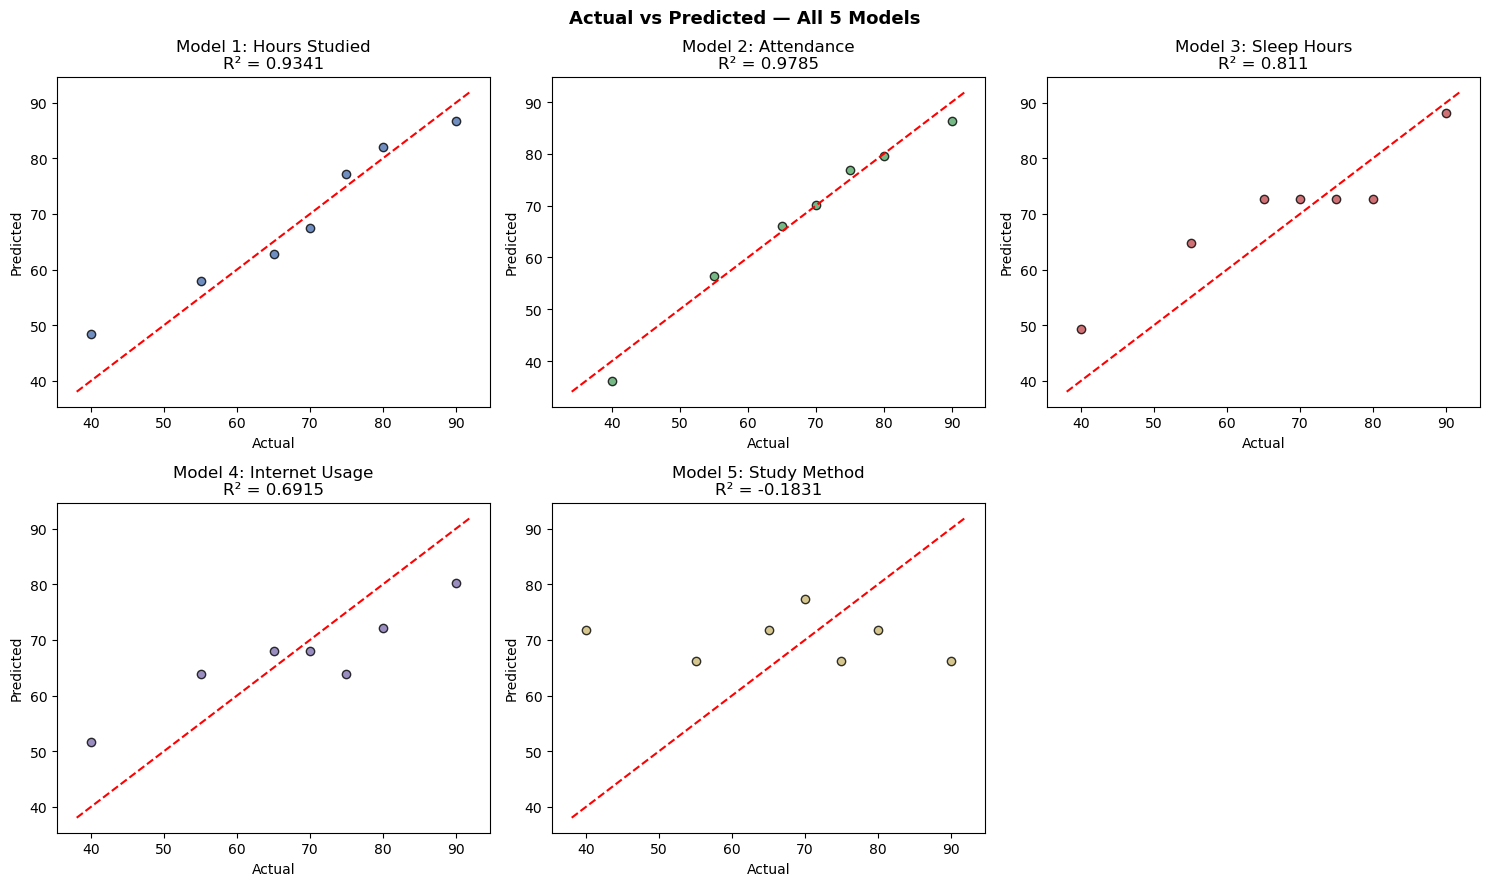

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, (y_test, y_pred)) in enumerate(predictions.items()):
    lo, hi = min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2
    axes[i].scatter(y_test, y_pred, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].plot([lo, hi], [lo, hi], 'r--')
    axes[i].set_title(f"{name}\nR² = {results[i]['R² Score']}")
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

axes[5].axis('off')
plt.suptitle('Actual vs Predicted — All 5 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Best Performing Model

In [12]:
best = results_df.loc[results_df['R² Score'].idxmax()]
print(f"Best Model : {best['Model']}")
print(f"Feature    : {best['Feature']}")
print(f"MAE        : {best['MAE']}")
print(f"MSE        : {best['MSE']}")
print(f"R² Score   : {best['R² Score']}")

Best Model : Model 2: Attendance
Feature    : Attendance
MAE        : 1.7629
MSE        : 5.0478
R² Score   : 0.9785


In [13]:
results_df.sort_values('R² Score', ascending=False).reset_index(drop=True)

,Model,Feature,MAE,MSE,R² Score
0,Model 2: Attendance,Attendance,1.7629,5.0478,0.9785
1,Model 1: Hours Studied,Hours_Studied,3.3346,15.4695,0.9341
2,Model 3: Sleep Hours,Sleep_Hours,5.8396,44.3541,0.8110
3,Model 4: Internet Usage,Internet_Usage,7.7457,72.3958,0.6915
4,Model 5: Study Method,Study_Method_Encoded,13.9754,277.6745,-0.1831
